In [1]:
# ==============================================================================
# PROYEK MACHINE LEARNING: KLASIFIKASI KELAYAKAN AIR MINUM (CRISP-DM)
# ==============================================================================

# 1. INSTALL LIBRARY
!pip install xgboost

# 2. IMPORT SEMUA LIBRARY YANG DIBUTUHKAN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Library berhasil di-import!")

✔ Library berhasil di-import!


In [6]:
# 3. LOAD DATASET DAN DATA UNDERSTANDING (CEK MISSING VALUES)
df = pd.read_csv('water_potability.csv')
print(df.shape)
print(df.info())
print("\n--- Jumlah Nilai Kosong per Kolom ---")
print(df.isnull().sum())

(3276, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB
None

--- Jumlah Nilai Kosong per Kolom ---
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtyp

In [10]:
# 4. DATA PREPARATION (IMPUTASI MEDIAN & SPLITTING)
# Mengisi missing values dengan median agar tidak merusak distribusi data asli
df['ph'] = df['ph'].fillna(df['ph'].median())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].median())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].median())

print("Pembersihan Selesai! Cek ulang nilai kosong:")
print(df.isnull().sum())

# Memisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['Potability'])
y = df['Potability']

# Membagi data menjadi 80% Train dan 20% Test dengan Stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Pembagian Data Sukses! Data Train: {X_train.shape[0]}, Data Test: {X_test.shape[0]}")


✔ Pembersihan Selesai! Cek ulang nilai kosong:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64
 Pembagian Data Sukses! Data Train: 2620, Data Test: 656


In [13]:
# 5. MODELING (ALGORITMA XGBOOST CLASSIFIER)
print("\n--- Melatih Model XGBoost ---")
model_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model_xgb.fit(X_train, y_train)
print("✔ Model XGBoost Berhasil Dilatih!")


--- Melatih Model XGBoost ---
✔ Model XGBoost Berhasil Dilatih!


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:54:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



================ EVALUASI MODEL ================
Akurasi Final Model: 66.77%

Laporan Klasifikasi Detail:
              precision    recall  f1-score   support

           0       0.67      0.89      0.77       400
           1       0.65      0.32      0.43       256

    accuracy                           0.67       656
   macro avg       0.66      0.61      0.60       656
weighted avg       0.66      0.67      0.64       656



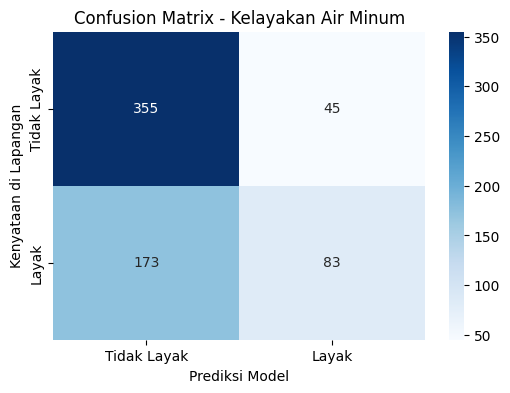

In [14]:
# 6. EVALUATION (MENGUJI PERFORMA MODEL)
y_pred = model_xgb.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print("\n================ EVALUASI MODEL ================")
print(f"Akurasi Final Model: {akurasi * 100:.2f}%")
print("\nLaporan Klasifikasi Detail:")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tidak Layak', 'Layak'], yticklabels=['Tidak Layak', 'Layak'])
plt.title('Confusion Matrix - Kelayakan Air Minum')
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan di Lapangan')
plt.savefig('confusion_matrix.png')
plt.show()

In [15]:
# 8. EXPORT MODEL UNTUK DEPLOYMENT STREAMLIT
pickle.dump(model_xgb, open('model_xgboost.pkl', 'wb'))
print("\n✔ File 'model_xgboost.pkl' berhasil dibuat! Silakan download dari panel kiri Colab.")


✔ File 'model_xgboost.pkl' berhasil dibuat! Silakan download dari panel kiri Colab.
